In [3]:
!wget https://ucilnica.fri.uni-lj.si/pluginfile.php/1187/course/overviewfiles/Screenshot%202024-02-16%20at%2002.55.38.png -O slika.png



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://ucilnica.fri.uni-lj.si]87Saving 'slika.png'
87slika.png            100% [=============================>]    2.49M    --.-KB/s87HTTP response 200  [https://ucilnica.fri.uni-lj.si/pluginfile.php/1187/course/overviewfiles/Screenshot%202024-02-16%20at%2002.55.38.png]
87slika.png            100% [=============================>]    2.49M    --.-KB/s87[Files: 1  Bytes: 2.49M [2.97MB]8

In [4]:
import numpy as np
import PIL.Image
import matplotlib.pyplot as plt
input_image = PIL.Image.open("slika.png")
input_image._getexif()

w, h = input_image.width, input_image.height
w,h

(1936, 1460)

In [31]:
ar = np.array(input_image)
mask = ar > 128
ar[mask] = 255
ar[~mask] = 0
ar= ar[:,:,0]


ar.shape

(1460, 1936)

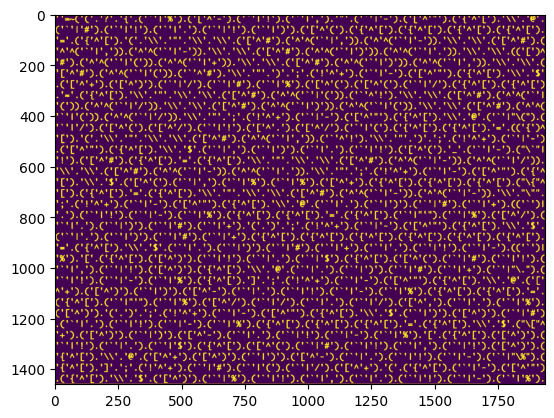

In [32]:
plt.imshow(ar)

In [22]:


def find_bounding_box(img, x, y):
    """
    Find the bounding box of an object in a binary image given a starting point (x, y).

    Args:
        img (numpy.ndarray): Binary image (0 for background, 255 for object).
        x (int): X-coordinate of the starting point.
        y (int): Y-coordinate of the starting point.

    Returns:
        tuple: Bounding box as (x_from, x_to, y_from, y_to).
               Returns None if the starting point is not part of an object.
    """
    # Ensure the image is binary (0 and 255)
    if not np.array_equal(np.unique(img), np.array([0, 255])):
        raise ValueError("Input image must be binary with values 0 and 255.")

    # Check if the starting point is valid and part of the object
    if img[y, x] != 255:
        return None  # Starting point is not part of an object
    
    # ymask = np.kron(np.arange(0, img.shape[0])[:, np.newaxis], np.ones(img.shape[1])[:, np.newaxis].T)
    # xmask = np.kron(np.arange(0, img.shape[1])[:, np.newaxis], np.ones(img.shape[0])[:, np.newaxis].T).T

    # print(ymask.shape, xmask.shape)
    


    # Create a mask to mark visited pixels
    mask = np.zeros_like(img, dtype=bool)

    # Initialize a stack for flood-fill
    stack = [(y, x)]

    # Initialize bounding box coordinates
    x_min, x_max = x, x
    y_min, y_max = y, y

    # Perform flood-fill to find all connected pixels
    while stack:
        cy, cx = stack.pop()
        if cx < 0 or cx >= img.shape[1] or cy < 0 or cy >= img.shape[0]:
            continue  # Out of bounds
        if img[cy, cx] != 255 or mask[cy, cx]:
            continue  # Not part of the object or already visited

        # Mark the pixel as visited
        mask[cy, cx] = True

        # Update bounding box coordinates
        x_min = min(x_min, cx)
        x_max = max(x_max, cx)
        y_min = min(y_min, cy)
        y_max = max(y_max, cy)

        # Add neighboring pixels to the stack
        stack.append((cy - 1, cx))  # Up
        stack.append((cy + 1, cx))  # Down
        stack.append((cy, cx - 1))  # Left
        stack.append((cy, cx + 1))  # Right

    return (x_min, x_max, y_min, y_max)

In [30]:
def parse_chars(input_image):
  for x in range(input_image.shape[1]):
    for y in range(input_image.shape[0]):
      if(input_image[y, x] == 255):
        # plt.imshow(input_image[y: y+200, x: x+200])
        # this is a new image part
        # find bounding box
        x_min, x_max, y_min, y_max = find_bounding_box(input_image, x,y)
        print(x_min, x_max, y_min, y_max)
        # plt.imshow(input_image[y_min:y_max, x_min:x_max])
        return
      
parse_chars(ar)

0 1700 1458 1459
